In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer

from imblearn.combine import SMOTEENN

from pycaret.regression import *
from pycaret.internal.preprocess.transformers import TransformerWrapper

import joblib # For store the PowerTrasnformers

### Innits


In [2]:
## GK
## ---> >60  = 2
## ---> cs*4
## ---> ((sv)/3)*1
## ---> gc
## ---> yc*-1


## DEF
## ---> >60  = 2
## ---> xg*6
## ---> xa*3
## ---> cs*4
## ---> gc
## ---> yc*-1


## MID
## ---> >60  = +2
## ---> xg*5
## ---> xa*3
## ---> cs*1
## ---> yc*-1


## FWD
## ---> >60  = 2
## ---> xg*4
## ---> xa*3
## ---> yc*-1

In [3]:
gw=35
data_22_23 = pd.read_csv('./data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('./data/joint/24-25/merged_player_data.csv')

data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] < gw]
data_24_25_test = data_24_25[data_24_25['event'] > gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])

data_36 = data_24_25_test[data_24_25_test['event'] == 36]
data_37 = data_24_25_test[data_24_25_test['event'] == 37]
data_38 = data_24_25_test[data_24_25_test['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

In [4]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Goals


## Def


In [5]:
def_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

xG
0.000000    4162
0.022126       1
0.443560       1
0.022259       1
0.598641       1
            ... 
0.063253       1
0.007494       1
0.113382       1
0.010312       1
0.048601       1
Name: count, Length: 2412, dtype: int64


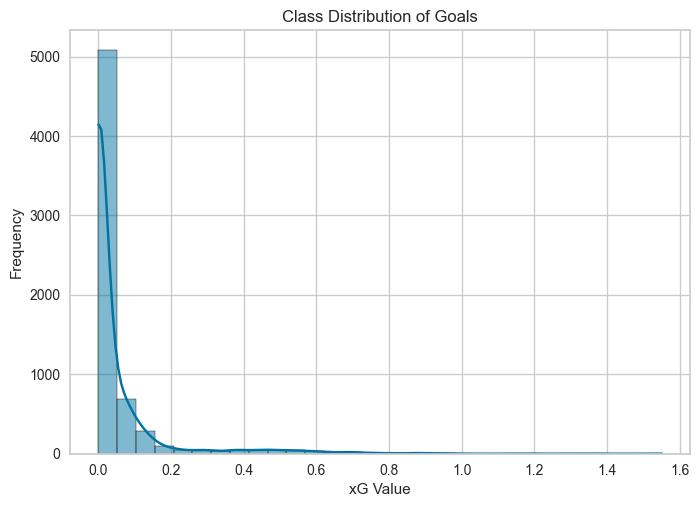

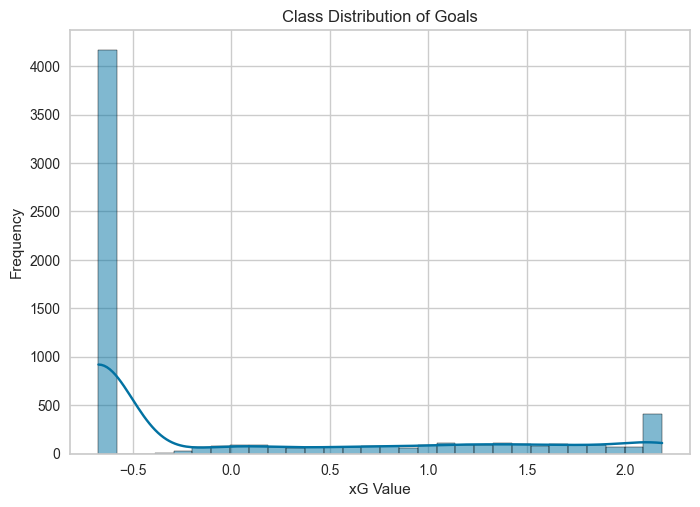

In [6]:

def_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xg_data = def_data[def_xg_features]
def_xg_data_tar = def_data_tar[def_xg_features]

def_data.reset_index(drop=True, inplace=True)
def_xg_data.reset_index(drop=True, inplace=True)

def_xg_data.drop(columns=['position'], inplace=True)
def_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(def_xg_data['xG'].value_counts())

sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xg.fit(def_xg_data[['xG']])
joblib.dump(pt_def_xg, './models/pt_def_xg.pkl')  # Save fitted transformer

def_xg_data['xG'] = pt_def_xg.transform(def_xg_data[['xG']])


sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [7]:
base_def_xg_model = setup(def_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xg_best = base_def_xg_model.compare_models(sort='MAE', n_select=1)
base_def_xg_best

# print('Tuning the model...')
# def_xg_base_tuned = tune_model(base_def_xg_best, search_library='optuna')



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002301 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5743
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 84
[LightGBM] [Info] Start training from score 0.004129


,Description,Value
0,Session id,2874
1,Target,xG
2,Target type,Regression
3,Original data shape,"(6573, 147)"
4,Transformed data shape,"(6573, 30)"
5,Transformed train set shape,"(5258, 30)"
6,Transformed test set shape,"(1315, 30)"
7,Numeric features,145
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3197,0.2916,0.5397,0.7080,0.2434,2.1971,2.0280
rf,Random Forest Regressor,0.3205,0.2979,0.5454,0.7018,0.2416,2.1535,3.5440
lightgbm,Light Gradient Boosting Machine,0.3313,0.3019,0.5492,0.6978,0.2474,2.0584,0.7360
gbr,Gradient Boosting Regressor,0.3345,0.2933,0.5414,0.7063,0.2493,2.1541,1.5720
xgboost,Extreme Gradient Boosting,0.3635,0.3388,0.5819,0.6610,0.2553,2.5727,0.9080
ada,AdaBoost Regressor,0.3750,0.3214,0.5666,0.6781,0.2410,2.1420,0.7030
dt,Decision Tree Regressor,0.3948,0.5673,0.7529,0.4318,0.2779,2.5423,0.5460
huber,Huber Regressor,0.4425,0.5108,0.7141,0.4893,0.3263,1.4494,0.6630
knn,K Neighbors Regressor,0.4582,0.4957,0.7035,0.5046,0.3052,1.8385,0.6600
ridge,Ridge Regression,0.5137,0.4704,0.6854,0.5296,0.3538,1.4807,0.9240


ExtraTreesRegressor(n_jobs=-1, random_state=2874)

In [8]:
evaluate_model(base_def_xg_best,)
# plot_model(base_fwd_y_best, plot='confusion_matrix')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

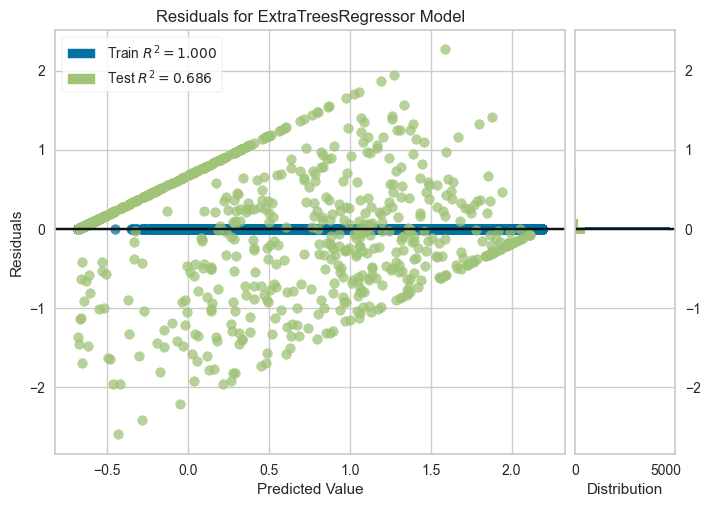

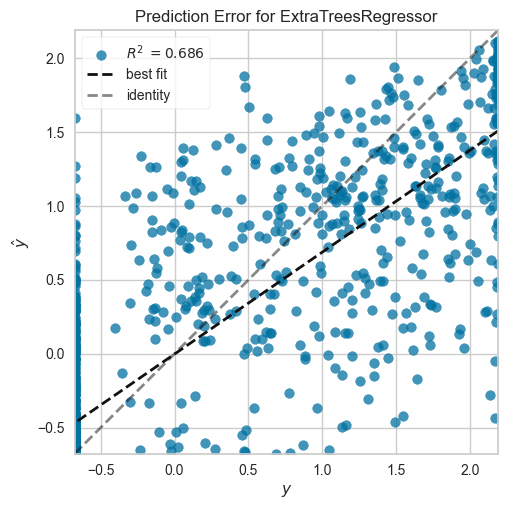

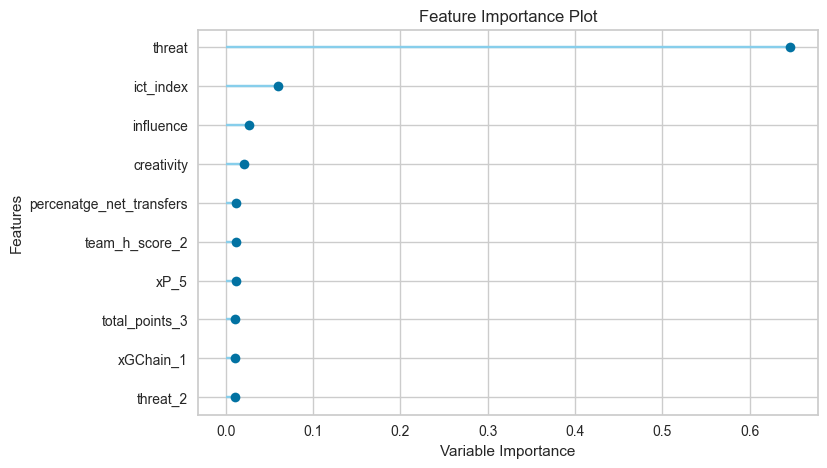

In [9]:
plot_model(base_def_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xg_best, plot='error')          # Prediction error plot
plot_model(base_def_xg_best, plot='feature')        # Feature importance

### Blended Model


In [10]:
blend_def_xg_model = setup(def_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

def_xg_best = compare_models(n_select=3, sort='MAE')
print(def_xg_best)

print('Blended model')
# Ensemble (blend or stack)
def_xg_blended = blend_models(def_xg_best, optimize='MAE')

# fwd_y_tuned = tune_model(fwd_y_blended, search_library='optuna', optimize='F1')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002995 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5797
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 86
[LightGBM] [Info] Start training from score -0.001236


,Description,Value
0,Session id,903
1,Target,xG
2,Target type,Regression
3,Original data shape,"(6573, 147)"
4,Transformed data shape,"(6573, 30)"
5,Transformed train set shape,"(5258, 30)"
6,Transformed test set shape,"(1315, 30)"
7,Numeric features,145
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3205,0.2973,0.5449,0.7003,0.2450,2.0967,3.5370
et,Extra Trees Regressor,0.3212,0.2937,0.5416,0.7040,0.2489,2.0776,1.7890
lightgbm,Light Gradient Boosting Machine,0.3323,0.3010,0.5481,0.6966,0.2519,1.9806,0.7250
gbr,Gradient Boosting Regressor,0.3363,0.2957,0.5434,0.7020,0.2503,1.9899,1.6390
xgboost,Extreme Gradient Boosting,0.3583,0.3300,0.5740,0.6676,0.2528,2.0627,0.9810
ada,AdaBoost Regressor,0.3781,0.3249,0.5697,0.6723,0.2443,2.1445,0.6990
dt,Decision Tree Regressor,0.3966,0.5720,0.7556,0.4235,0.2735,2.6706,0.5970
huber,Huber Regressor,0.4436,0.5097,0.7136,0.4872,0.3256,1.4159,0.7550
knn,K Neighbors Regressor,0.4646,0.5032,0.7086,0.4934,0.3094,1.5725,0.5810
lr,Linear Regression,0.5128,0.4708,0.6860,0.5262,0.3533,1.4914,0.5250


[RandomForestRegressor(n_jobs=-1, random_state=903), ExtraTreesRegressor(n_jobs=-1, random_state=903), LGBMRegressor(n_jobs=-1, random_state=903)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3325,0.3050,0.5523,0.6955,0.2524,0.9680
1,0.3211,0.2922,0.5406,0.7196,0.2534,6.3364
2,0.3165,0.2835,0.5325,0.7014,0.2378,1.3857
3,0.3495,0.3366,0.5801,0.6539,0.2582,1.3151
4,0.3321,0.3110,0.5577,0.6742,0.2674,1.4842
5,0.3034,0.2657,0.5155,0.7402,0.2341,2.6588
6,0.3198,0.2909,0.5394,0.7202,0.2468,2.1204
7,0.3083,0.2701,0.5197,0.7125,0.2441,1.2023
8,0.3100,0.2589,0.5089,0.7458,0.2390,2.0692


### Save Model


In [11]:
# # Patch method to prevent column reordering errors
# def _reorder_cols(self, df, original_df):
#     # Just return df without modifying columns
#     return df

# Apply patch
# TransformerWrapper._reorder_cols = _reorder_cols
def_xg_final_model = finalize_model(base_def_xg_best)
save_model(def_xg_final_model, './models/def_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## Mid


In [12]:
mid_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

xG
0.000000    2501
0.761169      11
0.761169       3
0.052510       2
0.423129       1
            ... 
0.103368       1
0.078944       1
0.051074       1
0.104148       1
0.036180       1
Name: count, Length: 4563, dtype: int64


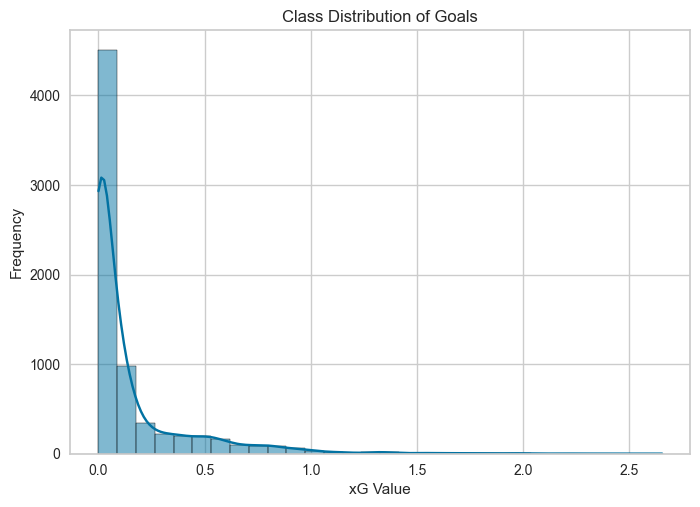

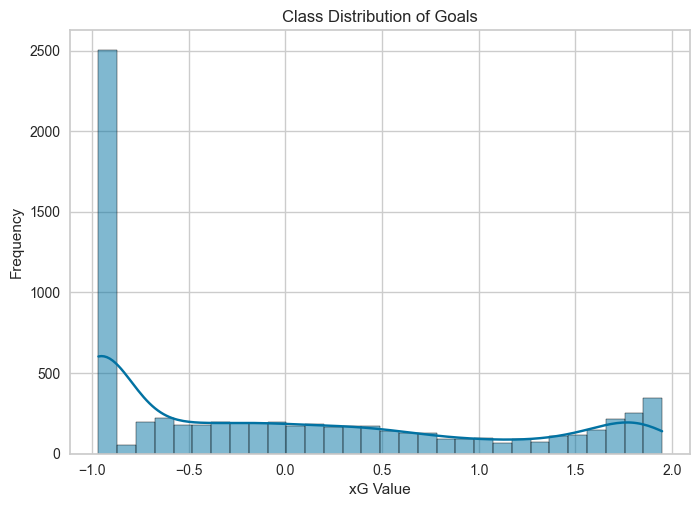

In [13]:

mid_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xg_data = mid_data[mid_xg_features]
mid_xg_data_tar = mid_data_tar[mid_xg_features]

mid_data.reset_index(drop=True, inplace=True)
mid_xg_data.reset_index(drop=True, inplace=True)

mid_xg_data.drop(columns=['position'], inplace=True)
mid_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(mid_xg_data['xG'].value_counts())

sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_mid_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_mid_xg.fit(mid_xg_data[['xG']])
joblib.dump(pt_mid_xg, './models/pt_mid_xg.pkl')  # Save fitted transformer

mid_xg_data['xG'] = pt_mid_xg.transform(mid_xg_data[['xG']])


sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [14]:
base_mid_xg_model = setup(mid_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xg_best = base_mid_xg_model.compare_models(sort='MAE', n_select=1)
base_mid_xg_best

# print('Tuning the model...')
# def_xg_base_tuned = tune_model(base_def_xg_best, search_library='optuna')



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006437 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7609
[LightGBM] [Info] Number of data points in the train set: 5660, number of used features: 84
[LightGBM] [Info] Start training from score 0.005450


,Description,Value
0,Session id,6137
1,Target,xG
2,Target type,Regression
3,Original data shape,"(7076, 147)"
4,Transformed data shape,"(7076, 30)"
5,Transformed train set shape,"(5660, 30)"
6,Transformed test set shape,"(1416, 30)"
7,Numeric features,145
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3691,0.2846,0.5329,0.7140,0.2636,23.3802,5.7080
et,Extra Trees Regressor,0.3716,0.2822,0.5307,0.7165,0.2613,28.2974,2.7470
lightgbm,Light Gradient Boosting Machine,0.3746,0.2856,0.5337,0.7131,0.2598,25.2803,0.9670
gbr,Gradient Boosting Regressor,0.3750,0.2771,0.5257,0.7217,0.2628,28.2242,1.8780
xgboost,Extreme Gradient Boosting,0.4025,0.3156,0.5611,0.6831,0.2701,27.4584,0.9460
ada,AdaBoost Regressor,0.4588,0.3300,0.5740,0.6683,0.2891,30.7742,0.9950
huber,Huber Regressor,0.4686,0.4139,0.6425,0.5843,0.2925,27.4414,0.8360
knn,K Neighbors Regressor,0.4736,0.4131,0.6421,0.5853,0.2943,31.9578,0.6500
dt,Decision Tree Regressor,0.4824,0.5571,0.7457,0.4394,0.3091,15.3769,0.7730
lr,Linear Regression,0.4836,0.3881,0.6222,0.6103,0.3042,23.2023,0.7050


RandomForestRegressor(n_jobs=-1, random_state=6137)

In [15]:
evaluate_model(base_mid_xg_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

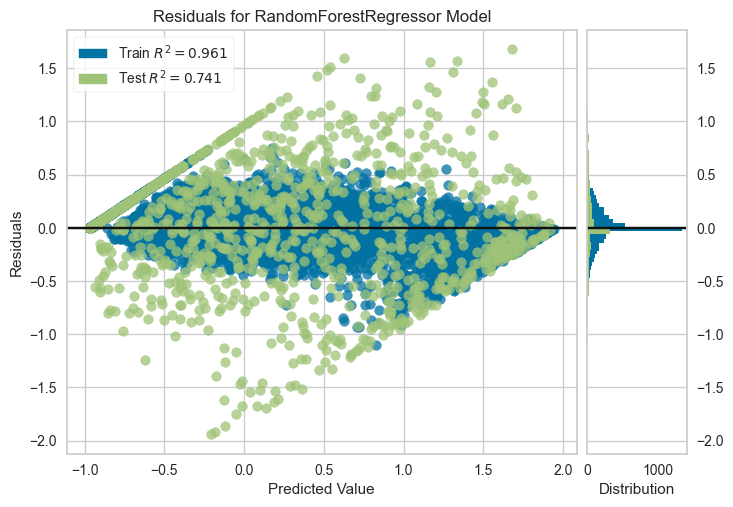

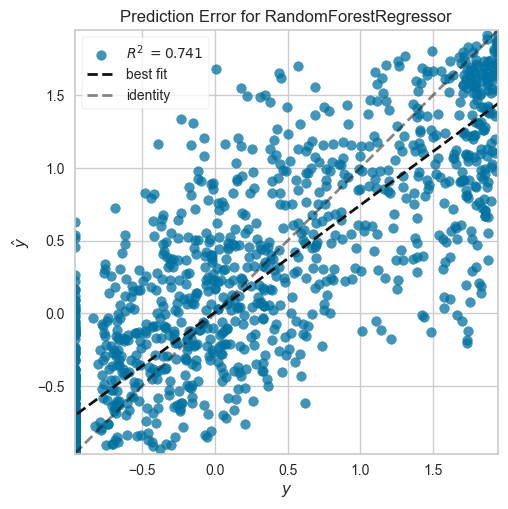

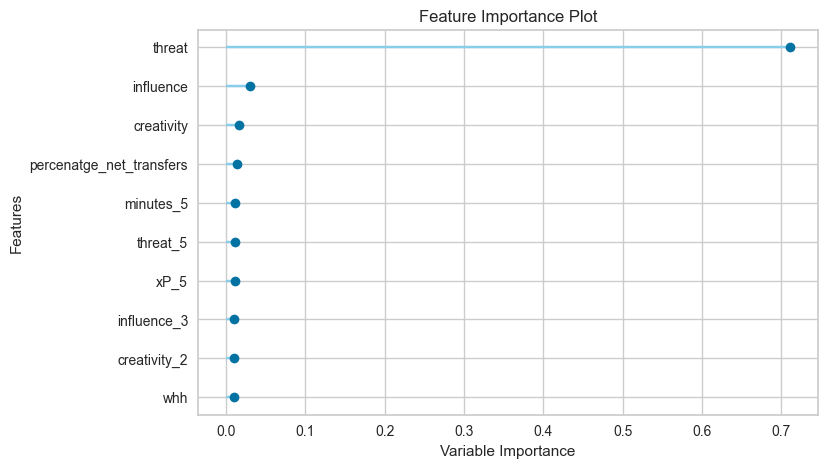

In [16]:
plot_model(base_mid_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xg_best, plot='error')          # Prediction error plot
plot_model(base_mid_xg_best, plot='feature')        # Feature importance

### Blended Model


In [17]:
blend_mid_xg_model = setup(mid_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

mid_xg_best = compare_models(n_select=3, sort='MAE')
print(mid_xg_best)

print('Blended model')
# Ensemble (blend or stack)
mid_xg_blended = blend_models(mid_xg_best, optimize='MAE')

# fwd_y_tuned = tune_model(fwd_y_blended, search_library='optuna', optimize='F1')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008299 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7473
[LightGBM] [Info] Number of data points in the train set: 5660, number of used features: 82
[LightGBM] [Info] Start training from score -0.000851


,Description,Value
0,Session id,8043
1,Target,xG
2,Target type,Regression
3,Original data shape,"(7076, 147)"
4,Transformed data shape,"(7076, 30)"
5,Transformed train set shape,"(5660, 30)"
6,Transformed test set shape,"(1416, 30)"
7,Numeric features,145
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3657,0.2793,0.5275,0.7212,0.2619,23.3269,5.7090
et,Extra Trees Regressor,0.3686,0.2789,0.5273,0.7215,0.2604,31.1576,2.5910
lightgbm,Light Gradient Boosting Machine,0.3707,0.2789,0.5272,0.7217,0.2605,33.8426,0.9100
gbr,Gradient Boosting Regressor,0.3716,0.2731,0.5216,0.7275,0.2616,35.1520,1.8850
xgboost,Extreme Gradient Boosting,0.3991,0.3109,0.5567,0.6900,0.2693,28.9871,1.1000
ada,AdaBoost Regressor,0.4298,0.3045,0.5512,0.6962,0.2785,32.3061,0.9010
knn,K Neighbors Regressor,0.4653,0.4015,0.6331,0.5994,0.2932,23.8941,0.8880
huber,Huber Regressor,0.4672,0.4169,0.6451,0.5849,0.2918,29.5080,0.7190
lr,Linear Regression,0.4836,0.3889,0.6232,0.6126,0.3047,23.2170,0.5930
ridge,Ridge Regression,0.4837,0.3888,0.6231,0.6127,0.3046,23.1772,0.6640


[RandomForestRegressor(n_jobs=-1, random_state=8043), ExtraTreesRegressor(n_jobs=-1, random_state=8043), LGBMRegressor(n_jobs=-1, random_state=8043)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3329,0.2335,0.4832,0.7686,0.2458,2.2556
1,0.3828,0.3031,0.5506,0.7050,0.2709,2.1517
2,0.3714,0.2895,0.5380,0.7222,0.2703,278.0411
3,0.3680,0.2712,0.5208,0.7226,0.2550,2.0155
4,0.3376,0.2336,0.4834,0.7499,0.2478,1.2608
5,0.3829,0.2809,0.5300,0.6989,0.2725,2.0550
6,0.3268,0.2209,0.4700,0.7884,0.2321,0.8991
7,0.3594,0.2636,0.5134,0.7462,0.2508,1.8101
8,0.3883,0.2979,0.5458,0.7225,0.2714,1.5877


### Save Model


In [18]:
mid_xg_final_model = finalize_model(mid_xg_blended)
save_model(mid_xg_final_model, './models/mid_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SelectFromModel(estimator=LGBMRegressor(),
                                               

## For


xG
0.000000    290
0.761169      7
0.208655      1
0.582700      1
0.366415      1
           ... 
0.583476      1
0.125661      1
1.442925      1
0.616388      1
0.326243      1
Name: count, Length: 1295, dtype: int64


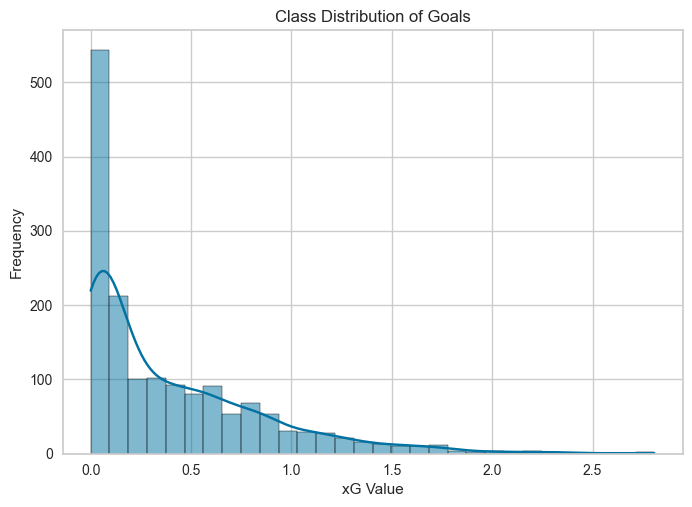

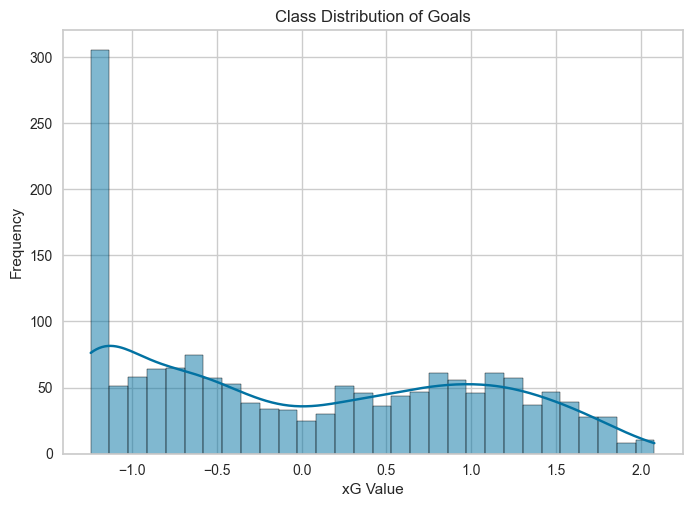

In [19]:
f_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',


            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]



fwd_xg_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xg_data = fwd_xg_data[f_xg_features]
fwd_xg_data_tar = fwd_data_tar[f_xg_features]

fwd_xg_data.reset_index(drop=True, inplace=True)
fwd_xg_data.reset_index(drop=True, inplace=True)

fwd_xg_data.drop(columns=['position'], inplace=True)
fwd_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(fwd_xg_data['xG'].value_counts())

sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_fwd_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_fwd_xg.fit(fwd_xg_data[['xG']])
joblib.dump(pt_fwd_xg, './models/pt_fwd_xg.pkl')  # Save fitted transformer

fwd_xg_data['xG'] = pt_fwd_xg.transform(fwd_xg_data[['xG']])


sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000800 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6368
[LightGBM] [Info] Number of data points in the train set: 1272, number of used features: 82
[LightGBM] [Info] Start training from score -0.013193


,Description,Value
0,Session id,1280
1,Target,xG
2,Target type,Regression
3,Original data shape,"(1590, 147)"
4,Transformed data shape,"(1590, 30)"
5,Transformed train set shape,"(1272, 30)"
6,Transformed test set shape,"(318, 30)"
7,Numeric features,145
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.4326,0.3194,0.5632,0.6723,0.2682,1.1347,0.8380
rf,Random Forest Regressor,0.4345,0.3275,0.5703,0.6639,0.2700,1.2029,1.4820
lightgbm,Light Gradient Boosting Machine,0.4432,0.3414,0.5824,0.6497,0.2629,1.2533,0.6270
et,Extra Trees Regressor,0.4473,0.3362,0.5778,0.6548,0.2761,1.2069,0.9560
xgboost,Extreme Gradient Boosting,0.4602,0.3633,0.6006,0.6268,0.2805,1.2311,0.5910
knn,K Neighbors Regressor,0.4821,0.3967,0.6279,0.5955,0.2801,1.3056,0.3440
huber,Huber Regressor,0.4972,0.4070,0.6364,0.5839,0.2787,1.2091,0.4000
lr,Linear Regression,0.5054,0.3819,0.6171,0.6096,0.2913,1.1372,0.5350
ridge,Ridge Regression,0.5054,0.3811,0.6163,0.6104,0.2910,1.1376,0.3400
br,Bayesian Ridge,0.5060,0.3836,0.6180,0.6074,0.2917,1.1161,0.3980


GradientBoostingRegressor(random_state=1280)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


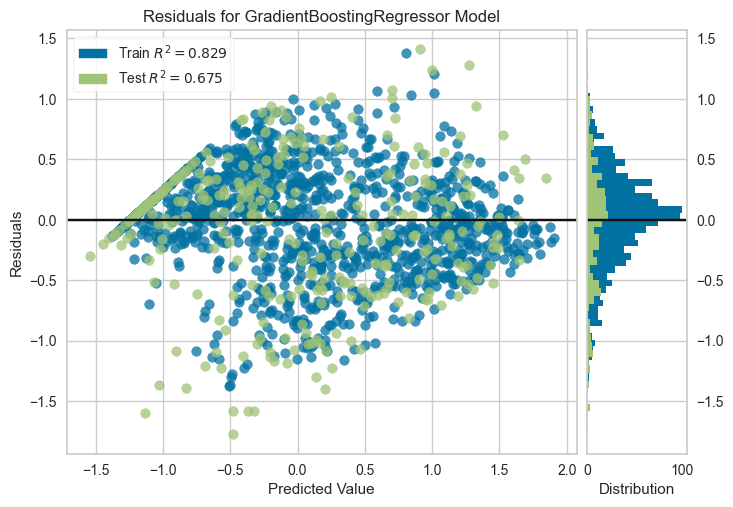

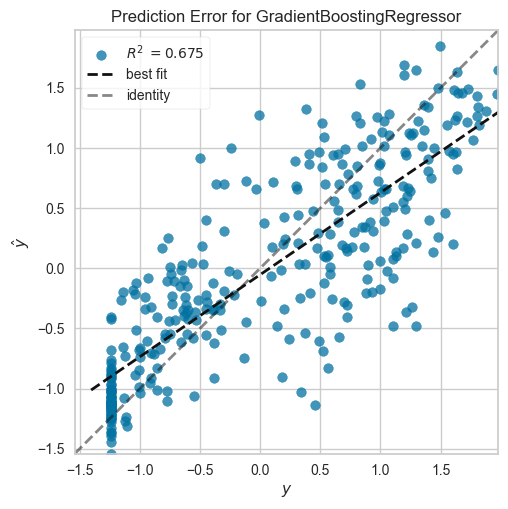

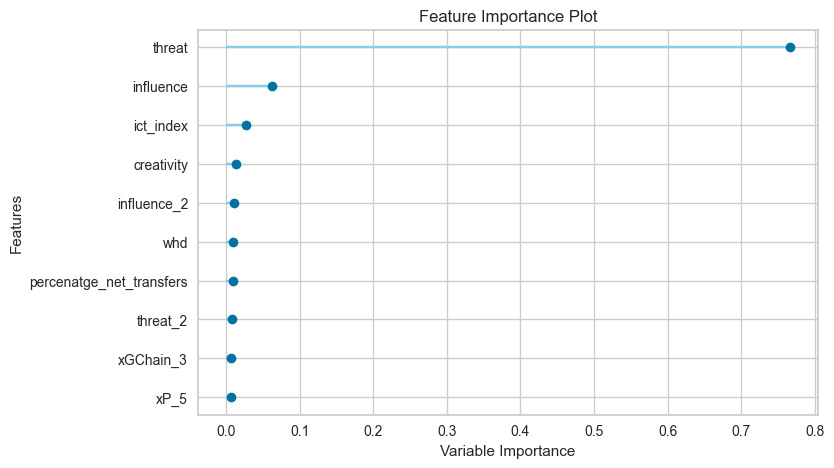

In [20]:
base_fwd_xg_model = setup(fwd_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xg_best = base_fwd_xg_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xg_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xg_best)

print('Plots...')
plot_model(base_fwd_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xg_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xg_best, plot='feature')        # Feature importance



### Blended Model


In [21]:
blend_fwd_xg_model = setup(fwd_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

fwd_xg_best = compare_models(n_select=3, sort='MAE')
print(fwd_xg_best)

print('Blended model')
# Ensemble (blend or stack)
fwd_xg_blended = blend_models(fwd_xg_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001736 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6647
[LightGBM] [Info] Number of data points in the train set: 1272, number of used features: 82
[LightGBM] [Info] Start training from score 0.003172


,Description,Value
0,Session id,5573
1,Target,xG
2,Target type,Regression
3,Original data shape,"(1590, 147)"
4,Transformed data shape,"(1590, 30)"
5,Transformed train set shape,"(1272, 30)"
6,Transformed test set shape,"(318, 30)"
7,Numeric features,145
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.4457,0.3279,0.5717,0.6598,0.2773,1.2516,0.7090
et,Extra Trees Regressor,0.4468,0.3308,0.5747,0.6573,0.2826,1.2273,0.9260
rf,Random Forest Regressor,0.4490,0.3349,0.5782,0.6531,0.2823,1.3078,1.4810
lightgbm,Light Gradient Boosting Machine,0.4520,0.3387,0.5813,0.6486,0.2712,1.3384,0.5180
xgboost,Extreme Gradient Boosting,0.4670,0.3730,0.6097,0.6124,0.2806,1.4044,0.7750
knn,K Neighbors Regressor,0.4934,0.4114,0.6402,0.5726,0.2897,1.3298,0.4730
lr,Linear Regression,0.5107,0.3869,0.6216,0.6008,0.2958,1.2031,0.3560
ridge,Ridge Regression,0.5108,0.3865,0.6213,0.6012,0.2960,1.2072,0.5790
huber,Huber Regressor,0.5124,0.4164,0.6447,0.5706,0.2906,1.3172,0.4100
br,Bayesian Ridge,0.5140,0.3903,0.6245,0.5976,0.2996,1.1786,0.3640


[GradientBoostingRegressor(random_state=5573), ExtraTreesRegressor(n_jobs=-1, random_state=5573), RandomForestRegressor(n_jobs=-1, random_state=5573)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4639,0.3330,0.5771,0.6668,0.2817,1.0246
1,0.4611,0.3179,0.5639,0.6623,0.2920,2.2646
2,0.3872,0.2521,0.5021,0.7667,0.2820,1.3268
3,0.4168,0.3327,0.5768,0.6776,0.2598,0.7438
4,0.4202,0.2921,0.5405,0.7174,0.2664,1.3004
5,0.4502,0.3404,0.5835,0.6306,0.2792,1.2832
6,0.4551,0.3209,0.5664,0.6612,0.3077,0.9120
7,0.4426,0.3473,0.5893,0.5818,0.2715,0.7458
8,0.4708,0.3394,0.5825,0.6558,0.2854,2.0020


### Save Model


In [22]:
fwd_xg_final_model = finalize_model(base_fwd_xg_best)
save_model(fwd_xg_final_model, './models/fwd_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

# Assists


In [23]:
xa_features = [ 'position',  'xA', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence',
                 'creativity', 'threat','starts',

            'expected_assists_1', 'expected_goal_involvements_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'shots_1','xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'shots_2', 'xA_2', 'assists_x_2',
            'assists_y_2',
            'key_passes_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'shots_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4',  'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'shots_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'shots_5',  'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

## Def


xA
0.000000    4470
0.059942       2
0.063347       1
0.108050       1
0.049833       1
            ... 
0.016065       1
0.037171       1
0.023500       1
0.013137       1
0.549479       1
Name: count, Length: 2103, dtype: int64


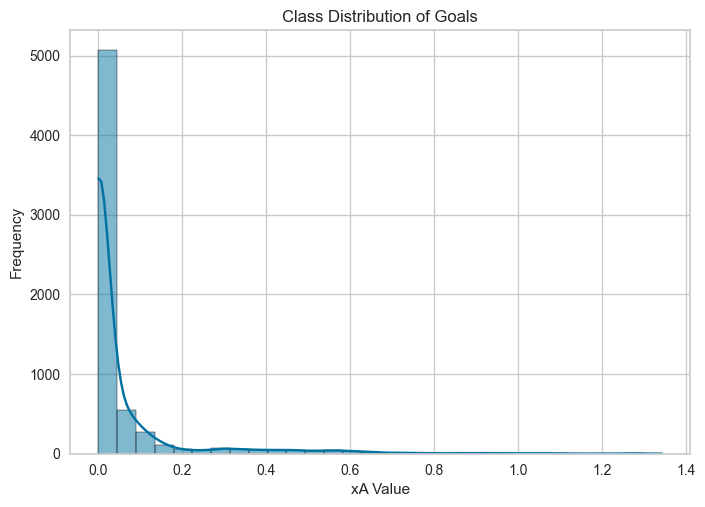

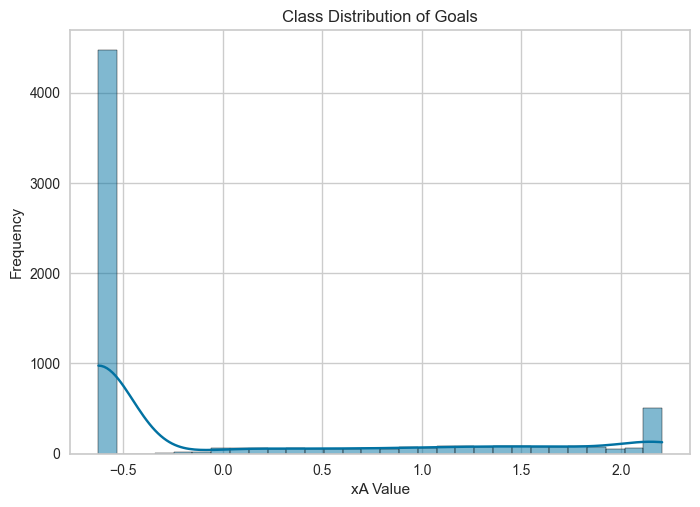

In [24]:
def_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xa_data = def_xa_data[xa_features]
def_xa_data_tar = def_xa_data_tar[xa_features]

def_xa_data.reset_index(drop=True, inplace=True)
def_xa_data.reset_index(drop=True, inplace=True)

def_xa_data.drop(columns=['position'], inplace=True)
def_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(def_xa_data['xA'].value_counts())

sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xa.fit(def_xa_data[['xA']])
joblib.dump(pt_def_xa, './models/pt_def_xa.pkl')  # Save fitted transformer

def_xa_data['xA'] = pt_def_xa.transform(def_xa_data[['xA']])


sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001759 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6197
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 77
[LightGBM] [Info] Start training from score -0.000689


,Description,Value
0,Session id,953
1,Target,xA
2,Target type,Regression
3,Original data shape,"(6573, 118)"
4,Transformed data shape,"(6573, 24)"
5,Transformed train set shape,"(5258, 24)"
6,Transformed test set shape,"(1315, 24)"
7,Numeric features,116
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.1925,0.1681,0.4094,0.8317,0.1828,0.9048,3.3700
et,Extra Trees Regressor,0.1944,0.1658,0.4067,0.8339,0.1833,0.8979,1.3050
gbr,Gradient Boosting Regressor,0.1990,0.1661,0.4069,0.8338,0.1809,0.9343,1.3620
lightgbm,Light Gradient Boosting Machine,0.2028,0.1763,0.4192,0.8236,0.1889,0.8989,0.7240
ada,AdaBoost Regressor,0.2083,0.1737,0.4163,0.8261,0.1872,0.9322,0.7420
xgboost,Extreme Gradient Boosting,0.2235,0.1997,0.4463,0.8001,0.2000,0.9146,0.6810
knn,K Neighbors Regressor,0.2494,0.2488,0.4985,0.7505,0.2294,0.8873,0.4290
dt,Decision Tree Regressor,0.2604,0.3409,0.5825,0.6581,0.2520,1.0253,0.4830
huber,Huber Regressor,0.3344,0.3739,0.6107,0.6250,0.2807,0.6014,0.6710
ridge,Ridge Regression,0.3896,0.3553,0.5955,0.6437,0.2856,0.7080,0.4220


RandomForestRegressor(n_jobs=-1, random_state=953)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


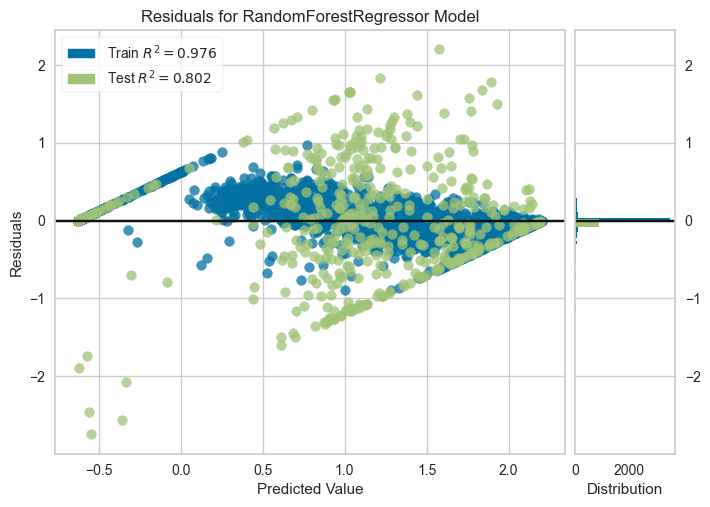

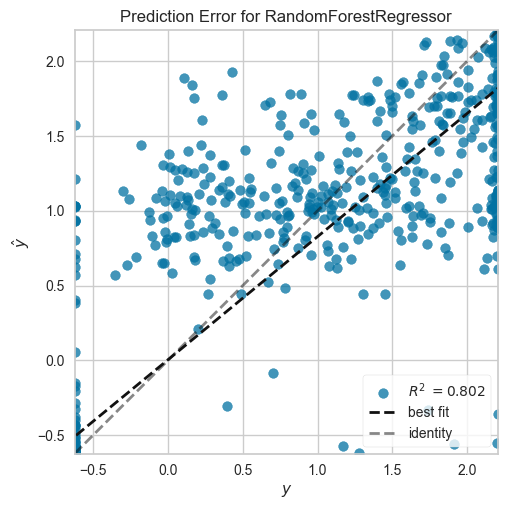

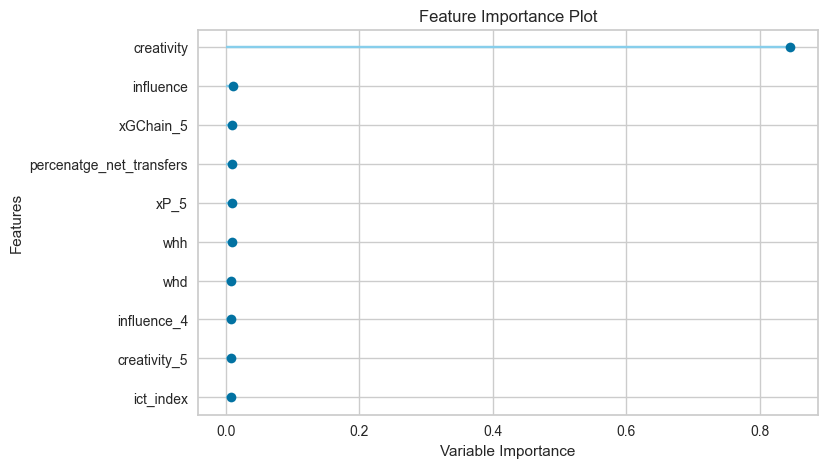

In [25]:
base_def_xa_model = setup(def_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xa_best = base_def_xa_model.compare_models(sort='MAE', n_select=1)
print(base_def_xa_best)

print('Évaluate the model...')
evaluate_model(base_def_xa_best)

print('Plots...')
plot_model(base_def_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xa_best, plot='error')          # Prediction error plot
plot_model(base_def_xa_best, plot='feature')        # Feature importance



### Blended Model


In [26]:
blend_def_xa_model = setup(def_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

def_xa_best = compare_models(n_select=3, sort='MAE')
print(def_xa_best)

print('Blended model')
# Ensemble (blend or stack)
def_xa_blended = blend_models(def_xa_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001886 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6064
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 77
[LightGBM] [Info] Start training from score 0.005607


,Description,Value
0,Session id,7532
1,Target,xA
2,Target type,Regression
3,Original data shape,"(6573, 118)"
4,Transformed data shape,"(6573, 24)"
5,Transformed train set shape,"(5258, 24)"
6,Transformed test set shape,"(1315, 24)"
7,Numeric features,116
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.1957,0.1750,0.4179,0.8271,0.1856,0.9617,3.1570
et,Extra Trees Regressor,0.2003,0.1752,0.4181,0.8268,0.1877,0.9705,1.3700
gbr,Gradient Boosting Regressor,0.2039,0.1733,0.4155,0.8289,0.1843,0.9901,1.3860
ada,AdaBoost Regressor,0.2094,0.1764,0.4193,0.8258,0.1874,0.9563,0.5950
lightgbm,Light Gradient Boosting Machine,0.2097,0.1862,0.4311,0.8158,0.1948,0.9899,0.6340
xgboost,Extreme Gradient Boosting,0.2271,0.2054,0.4529,0.7967,0.2056,1.0351,0.7900
knn,K Neighbors Regressor,0.2461,0.2490,0.4983,0.7541,0.2261,0.9322,0.5610
dt,Decision Tree Regressor,0.2549,0.3296,0.5739,0.6732,0.2511,1.0364,0.4980
huber,Huber Regressor,0.3388,0.3971,0.6282,0.6085,0.2840,0.6094,0.5050
ridge,Ridge Regression,0.4026,0.3744,0.6103,0.6308,0.2916,0.7375,0.5940


[RandomForestRegressor(n_jobs=-1, random_state=7532), ExtraTreesRegressor(n_jobs=-1, random_state=7532), GradientBoostingRegressor(random_state=7532)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1969,0.1657,0.4071,0.8272,0.1952,1.2100
1,0.2100,0.1870,0.4325,0.8296,0.1862,0.9873
2,0.2243,0.1957,0.4424,0.8112,0.1984,0.8291
3,0.1909,0.1678,0.4096,0.8371,0.1855,1.0915
4,0.1909,0.1546,0.3932,0.8450,0.1728,0.6062
5,0.2017,0.1813,0.4258,0.8124,0.1858,1.7958
6,0.1895,0.1662,0.4077,0.8322,0.1795,0.6143
7,0.1803,0.1391,0.3730,0.8534,0.1801,1.0469
8,0.1862,0.1596,0.3995,0.8400,0.1712,0.8178


### Save Model


In [27]:
def_xa_final_model = finalize_model(def_xa_blended)
save_model(def_xa_final_model, './models/def_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SelectFromModel(estimator=LGBMRegressor(),
                                              

## Mid


xA
0.000000    2859
0.107738       2
0.095407       1
0.023504       1
0.403232       1
            ... 
0.454983       1
0.081762       1
0.106337       1
0.115025       1
0.043413       1
Name: count, Length: 4217, dtype: int64


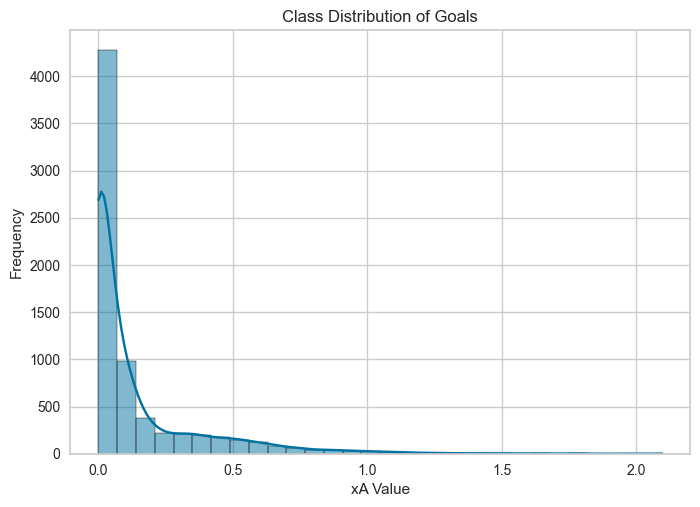

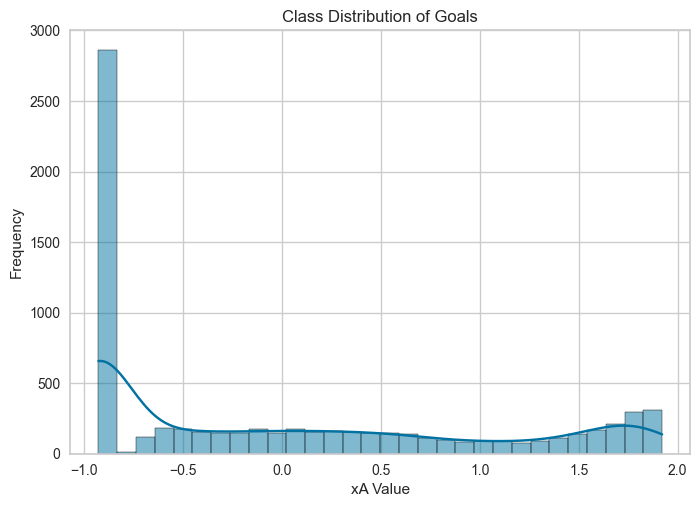

In [28]:

mid_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xa_data = mid_xa_data[xa_features]
mid_xa_data_tar = mid_xa_data_tar[xa_features]

mid_xa_data.reset_index(drop=True, inplace=True)
mid_xa_data.reset_index(drop=True, inplace=True)

mid_xa_data.drop(columns=['position'], inplace=True)
mid_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(mid_xa_data['xA'].value_counts())

sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_mid_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_mid_xa.fit(mid_xa_data[['xA']])
joblib.dump(pt_mid_xa, './models/pt_mid_xa.pkl')  # Save fitted transformer

mid_xa_data['xA'] = pt_mid_xa.transform(mid_xa_data[['xA']])


sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002755 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7364
[LightGBM] [Info] Number of data points in the train set: 5660, number of used features: 77
[LightGBM] [Info] Start training from score 0.004879


,Description,Value
0,Session id,6332
1,Target,xA
2,Target type,Regression
3,Original data shape,"(7076, 118)"
4,Transformed data shape,"(7076, 24)"
5,Transformed train set shape,"(5660, 24)"
6,Transformed test set shape,"(1416, 24)"
7,Numeric features,116
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3520,0.3017,0.5488,0.6972,0.2673,1.5496,4.3600
gbr,Gradient Boosting Regressor,0.3603,0.2970,0.5445,0.7019,0.2765,1.3781,1.7080
et,Extra Trees Regressor,0.3606,0.3046,0.5515,0.6942,0.2703,1.5284,1.9710
lightgbm,Light Gradient Boosting Machine,0.3632,0.3048,0.5517,0.6940,0.2726,1.4554,0.8000
xgboost,Extreme Gradient Boosting,0.3938,0.3377,0.5807,0.6607,0.2745,1.6236,1.2700
ada,AdaBoost Regressor,0.3960,0.3268,0.5716,0.6717,0.2475,1.7864,0.7820
huber,Huber Regressor,0.4338,0.4202,0.6474,0.5781,0.2968,1.2403,0.7650
knn,K Neighbors Regressor,0.4359,0.4070,0.6374,0.5916,0.2934,1.7223,0.5220
dt,Decision Tree Regressor,0.4640,0.5907,0.7681,0.4063,0.3168,2.6078,0.6850
ridge,Ridge Regression,0.4673,0.3977,0.6300,0.6008,0.3122,1.2086,0.5110


RandomForestRegressor(n_jobs=-1, random_state=6332)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


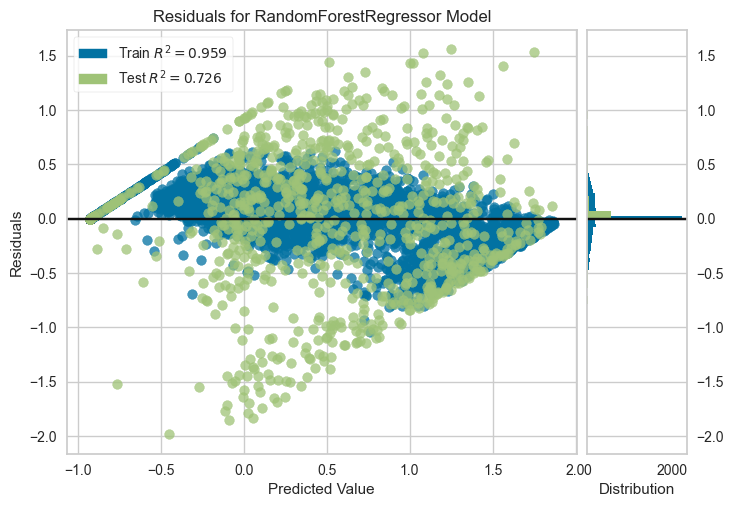

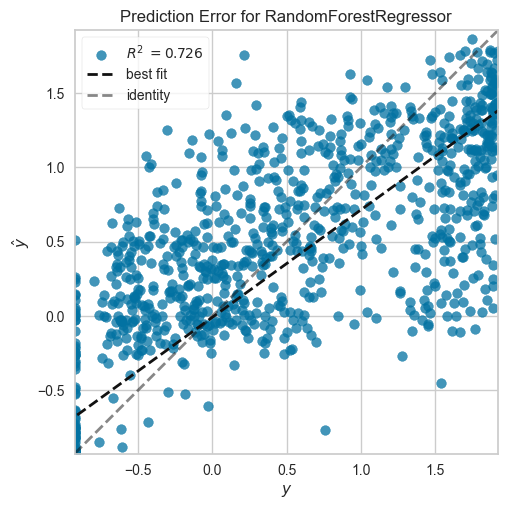

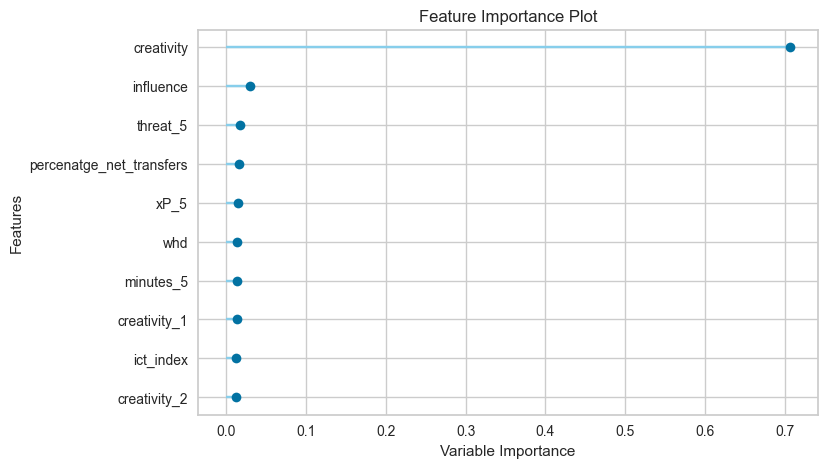

In [29]:
base_mid_xa_model = setup(mid_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xa_best = base_mid_xa_model.compare_models(sort='MAE', n_select=1)
print(base_mid_xa_best)

print('Évaluate the model...')
evaluate_model(base_mid_xa_best)

print('Plots...')
plot_model(base_mid_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xa_best, plot='error')          # Prediction error plot
plot_model(base_mid_xa_best, plot='feature')        # Feature importance



### Blended model


In [30]:
blend_mid_xa_model = setup(mid_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

mid_xa_best = compare_models(n_select=3, sort='MAE')
print(mid_xa_best)

print('Blended model')
# Ensemble (blend or stack)
mid_xa_blended = blend_models(mid_xa_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003748 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7510
[LightGBM] [Info] Number of data points in the train set: 5660, number of used features: 77
[LightGBM] [Info] Start training from score -0.008772


,Description,Value
0,Session id,3940
1,Target,xA
2,Target type,Regression
3,Original data shape,"(7076, 118)"
4,Transformed data shape,"(7076, 24)"
5,Transformed train set shape,"(5660, 24)"
6,Transformed test set shape,"(1416, 24)"
7,Numeric features,116
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3423,0.2910,0.5385,0.7079,0.2639,1.4786,4.1210
et,Extra Trees Regressor,0.3480,0.2914,0.5389,0.7075,0.2656,1.5163,2.0480
gbr,Gradient Boosting Regressor,0.3517,0.2877,0.5355,0.7112,0.2745,1.3923,1.8310
lightgbm,Light Gradient Boosting Machine,0.3533,0.2948,0.5421,0.7039,0.2661,1.4753,0.7620
ada,AdaBoost Regressor,0.3885,0.3157,0.5610,0.6830,0.2401,1.7436,0.7420
xgboost,Extreme Gradient Boosting,0.3893,0.3382,0.5808,0.6602,0.2731,1.7732,0.9520
huber,Huber Regressor,0.4263,0.4121,0.6412,0.5863,0.2925,1.2412,0.6410
knn,K Neighbors Regressor,0.4301,0.4096,0.6392,0.5882,0.2925,1.5922,0.5430
dt,Decision Tree Regressor,0.4559,0.5762,0.7583,0.4205,0.3121,2.5988,0.7040
lr,Linear Regression,0.4607,0.3894,0.6233,0.6090,0.3079,1.2145,0.5940


[RandomForestRegressor(n_jobs=-1, random_state=3940), ExtraTreesRegressor(n_jobs=-1, random_state=3940), GradientBoostingRegressor(random_state=3940)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3582,0.3013,0.5489,0.6944,0.2699,1.6782
1,0.3121,0.2416,0.4915,0.7594,0.2576,2.2697
2,0.3392,0.2863,0.5351,0.7143,0.2570,1.9249
3,0.3196,0.2619,0.5118,0.7393,0.2448,0.7222
4,0.3536,0.2977,0.5456,0.7022,0.2782,1.5576
5,0.3403,0.2752,0.5246,0.6998,0.2674,1.2368
6,0.3152,0.2366,0.4864,0.7543,0.2419,0.8646
7,0.3914,0.3400,0.5831,0.6547,0.2985,1.9100
8,0.3369,0.2667,0.5164,0.7330,0.2624,1.0573


### Save Model


In [31]:
mid_xa_final_model = finalize_model(mid_xa_blended)
save_model(mid_xa_final_model, './models/mid_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SelectFromModel(estimator=LGBMRegressor(),
                                              

## For


xA
0.000000    767
0.127663      1
0.077458      1
0.147103      1
0.733360      1
           ... 
0.414716      1
0.122116      1
0.031267      1
0.401950      1
0.048869      1
Name: count, Length: 824, dtype: int64


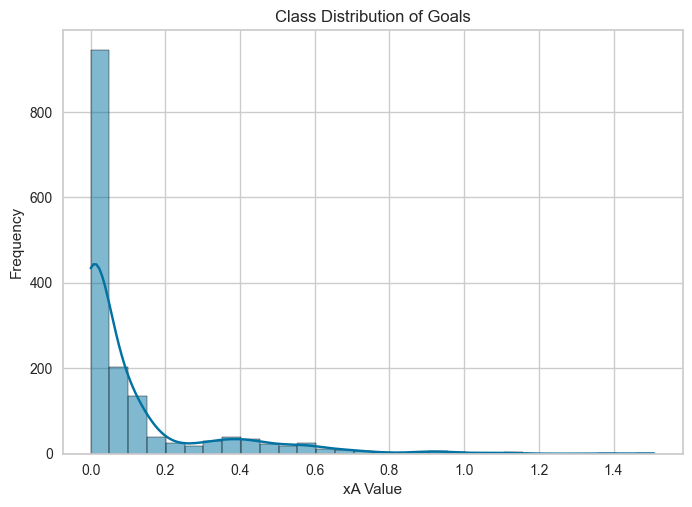

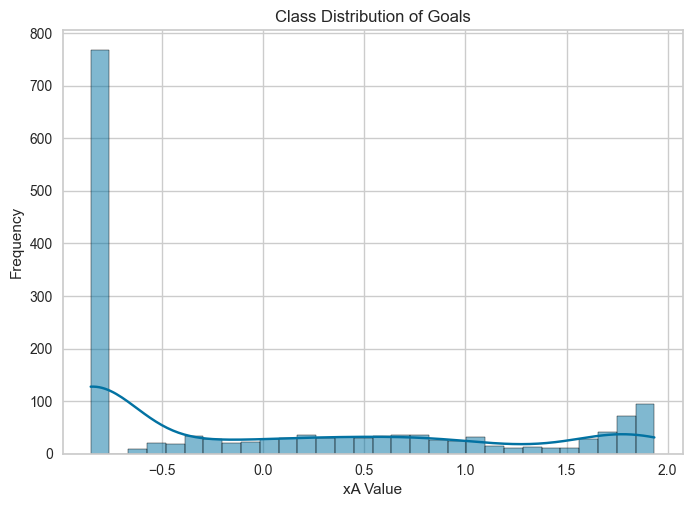

In [32]:

fwd_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xa_data = fwd_xa_data[xa_features]
fwd_xa_data_tar = fwd_xa_data_tar[xa_features]

fwd_xa_data.reset_index(drop=True, inplace=True)
fwd_xa_data.reset_index(drop=True, inplace=True)

fwd_xa_data.drop(columns=['position'], inplace=True)
fwd_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)



print(fwd_xa_data['xA'].value_counts())

sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_fwd_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_fwd_xa.fit(fwd_xa_data[['xA']])
joblib.dump(pt_fwd_xa, './models/pt_fwd_xa.pkl')  # Save fitted transformer

fwd_xa_data['xA'] = pt_fwd_xa.transform(fwd_xa_data[['xA']])


sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001466 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7223
[LightGBM] [Info] Number of data points in the train set: 1272, number of used features: 82
[LightGBM] [Info] Start training from score 0.010025


,Description,Value
0,Session id,4210
1,Target,xA
2,Target type,Regression
3,Original data shape,"(1590, 118)"
4,Transformed data shape,"(1590, 24)"
5,Transformed train set shape,"(1272, 24)"
6,Transformed test set shape,"(318, 24)"
7,Numeric features,116
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3230,0.2865,0.5332,0.7127,0.2384,1.0256,1.0500
et,Extra Trees Regressor,0.3267,0.2792,0.5264,0.7199,0.2357,0.9834,0.6720
gbr,Gradient Boosting Regressor,0.3321,0.2789,0.5254,0.7195,0.2314,0.9901,0.7090
lightgbm,Light Gradient Boosting Machine,0.3545,0.3080,0.5536,0.6896,0.2515,1.1163,0.5640
xgboost,Extreme Gradient Boosting,0.3625,0.3269,0.5703,0.6713,0.2580,1.1305,0.5180
huber,Huber Regressor,0.4105,0.3903,0.6221,0.6109,0.3017,0.7353,0.3740
dt,Decision Tree Regressor,0.4137,0.5405,0.7339,0.4572,0.2902,1.3738,0.3390
br,Bayesian Ridge,0.4379,0.3718,0.6074,0.6290,0.3061,0.7946,0.3660
ada,AdaBoost Regressor,0.4388,0.3203,0.5627,0.6789,0.2518,1.2957,0.4630
ridge,Ridge Regression,0.4393,0.3745,0.6094,0.6265,0.3056,0.7985,0.4440


RandomForestRegressor(n_jobs=-1, random_state=4210)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


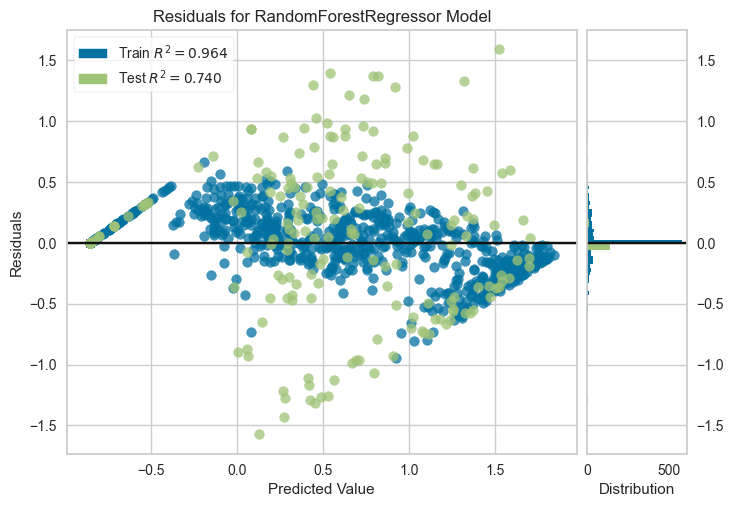

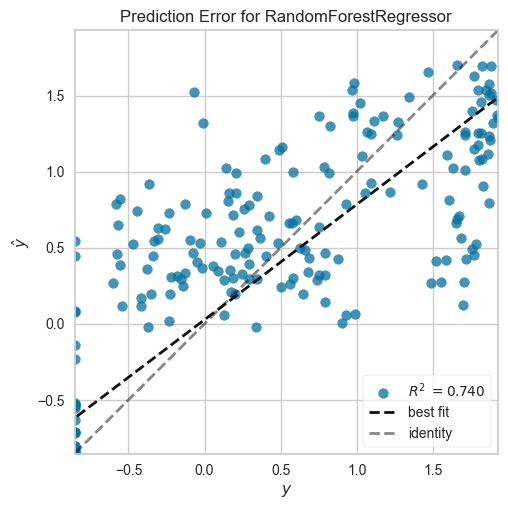

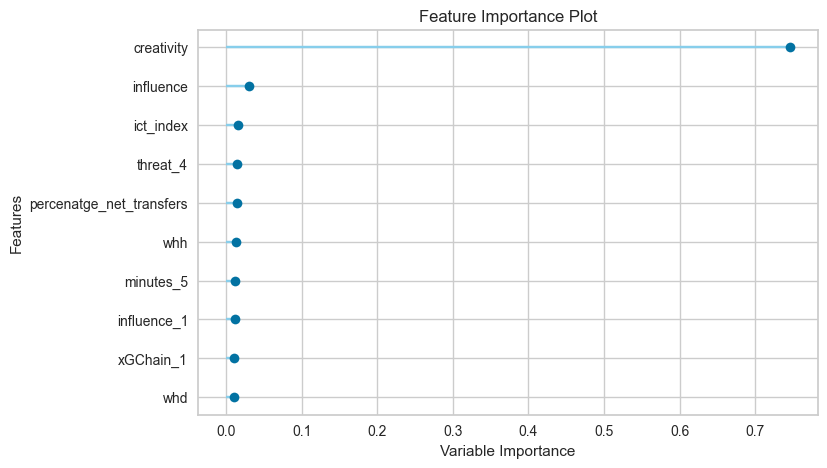

In [33]:
base_fwd_xa_model = setup(fwd_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xa_best = base_fwd_xa_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xa_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xa_best)

print('Plots...')
plot_model(base_fwd_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xa_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xa_best, plot='feature')        # Feature importance

### Blended model


In [34]:
blend_fwd_xa_model = setup(fwd_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

fwd_xa_best = compare_models(n_select=3, sort='MAE')
print(fwd_xa_best)

print('Blended model')
# Ensemble (blend or stack)
fwd_xa_blended = blend_models(fwd_xa_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001466 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7173
[LightGBM] [Info] Number of data points in the train set: 1272, number of used features: 82
[LightGBM] [Info] Start training from score 0.001022


,Description,Value
0,Session id,5119
1,Target,xA
2,Target type,Regression
3,Original data shape,"(1590, 118)"
4,Transformed data shape,"(1590, 24)"
5,Transformed train set shape,"(1272, 24)"
6,Transformed test set shape,"(318, 24)"
7,Numeric features,116
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3202,0.2769,0.5235,0.7181,0.2379,1.0328,0.9850
et,Extra Trees Regressor,0.3232,0.2716,0.5189,0.7239,0.2345,1.0038,0.7070
gbr,Gradient Boosting Regressor,0.3380,0.2815,0.5285,0.7131,0.2389,1.0807,0.6380
lightgbm,Light Gradient Boosting Machine,0.3468,0.2943,0.5390,0.7007,0.2463,1.1075,0.4700
xgboost,Extreme Gradient Boosting,0.3587,0.3276,0.5701,0.6668,0.2613,1.1505,0.6530
dt,Decision Tree Regressor,0.4014,0.5196,0.7156,0.4734,0.2979,1.3728,0.4530
huber,Huber Regressor,0.4121,0.3986,0.6284,0.5972,0.3050,0.7733,0.3450
ada,AdaBoost Regressor,0.4377,0.3190,0.5631,0.6750,0.2481,1.2592,0.4810
br,Bayesian Ridge,0.4396,0.3745,0.6097,0.6205,0.3064,0.8364,0.4350
ridge,Ridge Regression,0.4419,0.3792,0.6134,0.6158,0.3069,0.8682,0.3120


[RandomForestRegressor(n_jobs=-1, random_state=5119), ExtraTreesRegressor(n_jobs=-1, random_state=5119), GradientBoostingRegressor(random_state=5119)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3599,0.2912,0.5396,0.7343,0.2543,0.8914
1,0.3179,0.2730,0.5225,0.6839,0.2325,2.3008
2,0.2768,0.2518,0.5018,0.6870,0.2079,0.6216
3,0.3484,0.2901,0.5386,0.6688,0.2300,0.8115
4,0.3737,0.3420,0.5848,0.6977,0.2516,0.9705
5,0.3813,0.3387,0.5819,0.7004,0.2702,1.8148
6,0.3394,0.2824,0.5314,0.6779,0.2434,1.1084
7,0.3130,0.2371,0.4869,0.7840,0.2340,0.4149
8,0.2583,0.1905,0.4365,0.8105,0.1953,0.7051


### Save Model


In [35]:
fwd_xa_final_model = finalize_model(base_fwd_xa_best)
save_model(fwd_xa_final_model, './models/fwd_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


# Saves


## GK


saves
2     360
3     298
1     255
4     235
5     156
0     126
6      84
7      54
8      21
9      15
10      4
11      2
12      1
13      1
Name: count, dtype: int64


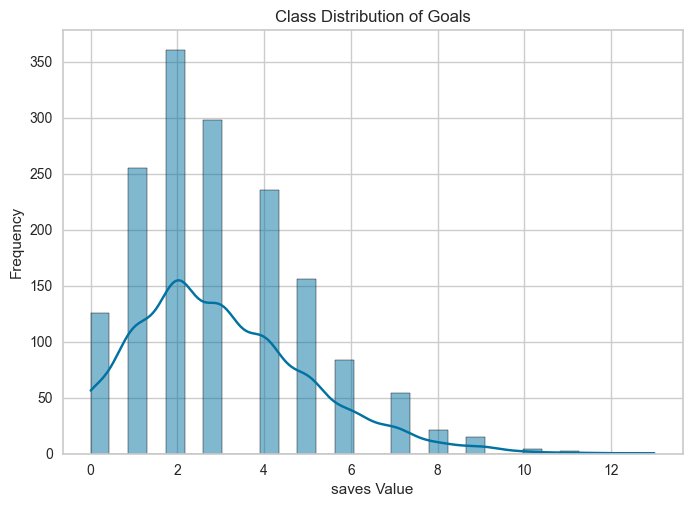

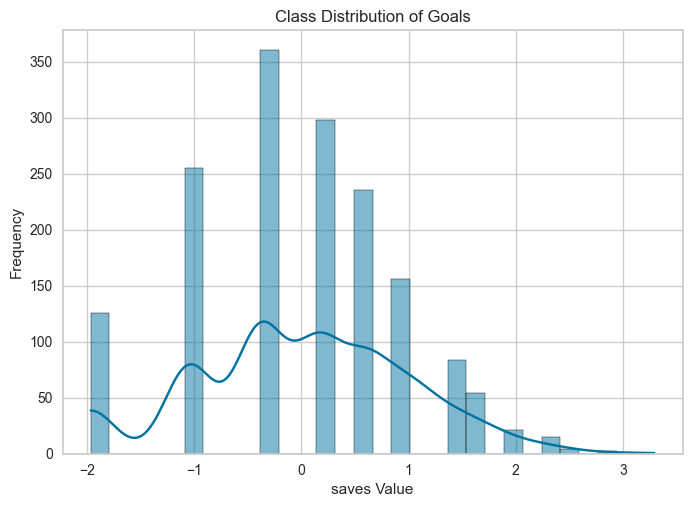

In [36]:
saves_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'saves',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



g_saves_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_saves_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_saves_data = g_saves_data[saves_features]
g_saves_data_tar = g_saves_data_tar[saves_features]

g_saves_data.reset_index(drop=True, inplace=True)
g_saves_data.reset_index(drop=True, inplace=True)

g_saves_data.drop(columns=['position'], inplace=True)
g_saves_data_tar.drop(columns=['position', 'saves'], inplace=True)

print(g_saves_data['saves'].value_counts())

sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

pt_gk_saves = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_gk_saves.fit(g_saves_data[['saves']])
joblib.dump(pt_gk_saves, './models/pt_gk_saves.pkl')  # Save fitted transformer

g_saves_data['saves'] = pt_gk_saves.transform(g_saves_data[['saves']])


sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000425 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2973
[LightGBM] [Info] Number of data points in the train set: 1289, number of used features: 65
[LightGBM] [Info] Start training from score -0.009000


,Description,Value
0,Session id,214
1,Target,saves
2,Target type,Regression
3,Original data shape,"(1612, 116)"
4,Transformed data shape,"(1612, 24)"
5,Transformed train set shape,"(1289, 24)"
6,Transformed test set shape,"(323, 24)"
7,Numeric features,114
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.2849,0.1563,0.3942,0.8416,0.1918,0.6527,0.5860
rf,Random Forest Regressor,0.2899,0.1650,0.4053,0.8330,0.1980,0.6643,0.9180
et,Extra Trees Regressor,0.2931,0.1641,0.4041,0.8339,0.1981,0.6778,0.6270
lightgbm,Light Gradient Boosting Machine,0.2991,0.1703,0.4113,0.8283,0.2028,0.6958,0.3770
xgboost,Extreme Gradient Boosting,0.3094,0.1836,0.4273,0.8142,0.2110,0.7130,0.4180
br,Bayesian Ridge,0.3191,0.1926,0.4373,0.8059,0.2051,0.7012,0.2530
ridge,Ridge Regression,0.3193,0.1927,0.4374,0.8057,0.2062,0.7028,0.2570
lr,Linear Regression,0.3195,0.1927,0.4374,0.8056,0.2063,0.7029,0.2980
omp,Orthogonal Matching Pursuit,0.3198,0.1952,0.4404,0.8032,0.2044,0.7032,0.2440
en,Elastic Net,0.3240,0.1964,0.4419,0.8019,0.2070,0.6927,0.3200


GradientBoostingRegressor(random_state=214)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


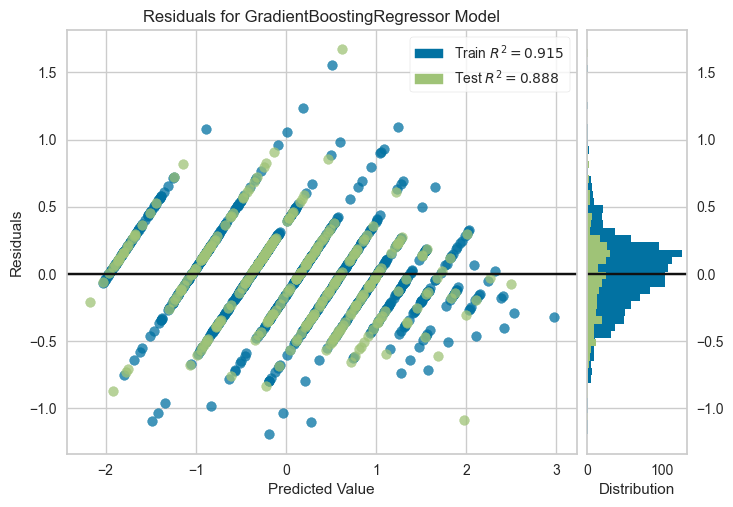

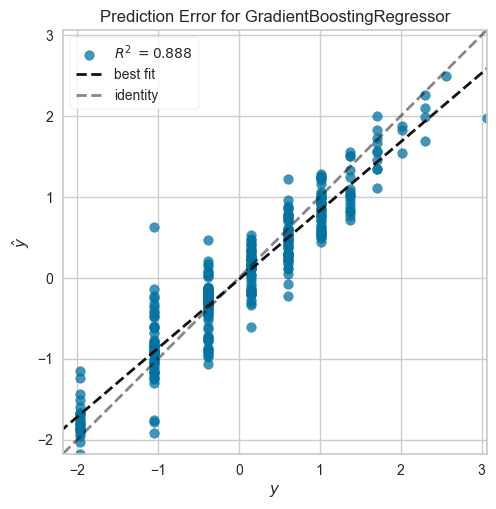

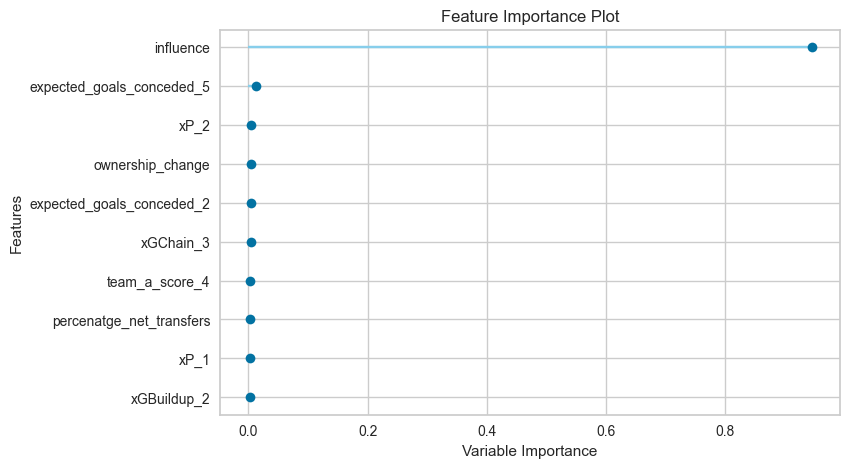

In [37]:
base_g_saves_model = setup(g_saves_data, target = 'saves',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_saves_best = base_g_saves_model.compare_models(sort='MAE', n_select=1)
print(base_g_saves_best)

print('Évaluate the model...')
evaluate_model(base_g_saves_best)

print('Plots...')
plot_model(base_g_saves_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_saves_best, plot='error')          # Prediction error plot
plot_model(base_g_saves_best, plot='feature')        # Feature importance

### Blended Model


In [38]:
blend_g_saves_model = setup(g_saves_data, target = 'saves',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

g_saves_best = compare_models(n_select=3, sort='MAE')
print(g_saves_best)

print('Blended model')
# Ensemble (blend or stack)
g_saves_blended = blend_models(g_saves_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3015
[LightGBM] [Info] Number of data points in the train set: 1289, number of used features: 67
[LightGBM] [Info] Start training from score 0.015451


,Description,Value
0,Session id,8413
1,Target,saves
2,Target type,Regression
3,Original data shape,"(1612, 116)"
4,Transformed data shape,"(1612, 24)"
5,Transformed train set shape,"(1289, 24)"
6,Transformed test set shape,"(323, 24)"
7,Numeric features,114
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.2787,0.1492,0.3837,0.8503,0.1885,0.6206,0.4870
rf,Random Forest Regressor,0.2826,0.1520,0.3875,0.8475,0.1912,0.6272,0.9590
et,Extra Trees Regressor,0.2845,0.1529,0.3888,0.8466,0.1912,0.6313,0.5220
lightgbm,Light Gradient Boosting Machine,0.2917,0.1604,0.3979,0.8394,0.1966,0.6630,0.5140
xgboost,Extreme Gradient Boosting,0.3073,0.1772,0.4189,0.8225,0.2060,0.7009,0.4040
br,Bayesian Ridge,0.3176,0.1890,0.4328,0.8107,0.2045,0.6736,0.3280
omp,Orthogonal Matching Pursuit,0.3183,0.1904,0.4345,0.8092,0.2037,0.6732,0.3000
ridge,Ridge Regression,0.3195,0.1897,0.4337,0.8099,0.2061,0.6793,0.3310
lr,Linear Regression,0.3199,0.1899,0.4339,0.8097,0.2063,0.6800,0.2530
en,Elastic Net,0.3219,0.1917,0.4359,0.8081,0.2063,0.6628,0.2550


[GradientBoostingRegressor(random_state=8413), RandomForestRegressor(n_jobs=-1, random_state=8413), ExtraTreesRegressor(n_jobs=-1, random_state=8413)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2651,0.1314,0.3624,0.8757,0.1786,0.4868
1,0.2650,0.1249,0.3534,0.8788,0.1918,0.5623
2,0.2976,0.1876,0.4332,0.7942,0.1973,0.6993
3,0.2670,0.1442,0.3798,0.8615,0.1851,0.5947
4,0.2562,0.1027,0.3204,0.8983,0.1682,0.6463
5,0.2571,0.1141,0.3378,0.8834,0.1769,0.5047
6,0.3187,0.2001,0.4473,0.7774,0.2124,0.8190
7,0.2406,0.1119,0.3345,0.8758,0.1669,0.6316
8,0.3037,0.1695,0.4116,0.8471,0.2045,0.6211


### Save Model


In [39]:
g_saves_final_model = finalize_model(base_g_saves_best)
save_model(g_saves_final_model, './models/g_saves_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
 

# Goals Conceded


In [40]:
xgc_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',

            'expected_goals_conceded',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3',  'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]

## GK


expected_goals_conceded
1.48    19
0.83    17
1.03    14
1.32    13
1.12    13
        ..
3.22     1
2.62     1
3.52     1
3.70     1
3.60     1
Name: count, Length: 344, dtype: int64


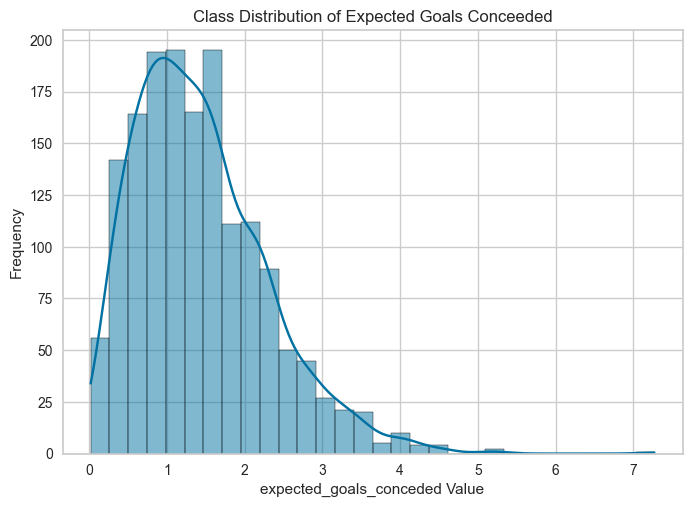

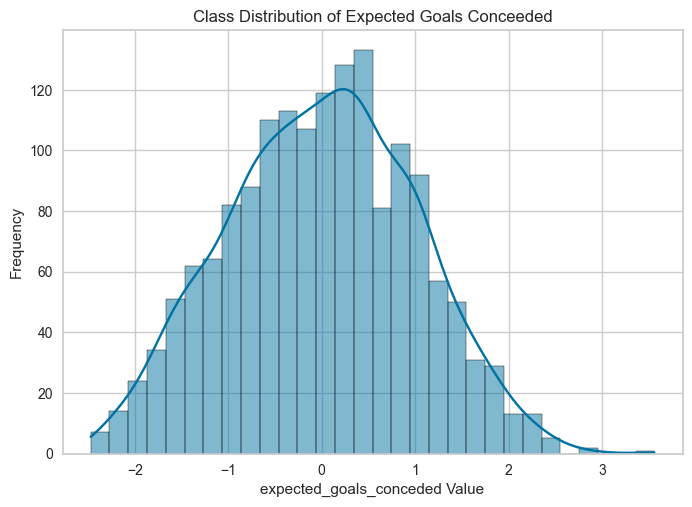

In [41]:
g_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_xgc_data = g_xgc_data[xgc_features]
g_xgc_data_tar = g_xgc_data_tar[xgc_features]

g_xgc_data.reset_index(drop=True, inplace=True)
g_xgc_data.reset_index(drop=True, inplace=True)

g_xgc_data.drop(columns=['position'], inplace=True)
g_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(g_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt_gk_xgc = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_gk_xgc.fit(g_xgc_data[['expected_goals_conceded']])
joblib.dump(pt_gk_xgc, './models/pt_gk_xgc.pkl')  # Save fitted transformer

g_xgc_data['expected_goals_conceded'] = pt_gk_xgc.transform(g_xgc_data[['expected_goals_conceded']])


sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001349 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3015
[LightGBM] [Info] Number of data points in the train set: 1289, number of used features: 66
[LightGBM] [Info] Start training from score -0.008197


,Description,Value
0,Session id,8221
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(1612, 108)"
4,Transformed data shape,"(1612, 22)"
5,Transformed train set shape,"(1289, 22)"
6,Transformed test set shape,"(323, 22)"
7,Numeric features,106
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.7150,0.7660,0.8737,0.2361,0.4146,1.8566,0.7250
gbr,Gradient Boosting Regressor,0.7164,0.7677,0.8744,0.2352,0.4138,1.9409,0.4710
rf,Random Forest Regressor,0.7192,0.7792,0.8811,0.2231,0.4214,1.9617,1.1320
ridge,Ridge Regression,0.7205,0.7708,0.8765,0.2314,0.4065,1.8850,0.3210
lr,Linear Regression,0.7209,0.7720,0.8772,0.2302,0.4065,1.9061,0.3270
br,Bayesian Ridge,0.7220,0.7700,0.8758,0.2324,0.4097,1.8064,0.2890
ada,AdaBoost Regressor,0.7274,0.7816,0.8829,0.2199,0.4492,1.6813,0.4470
omp,Orthogonal Matching Pursuit,0.7397,0.8045,0.8951,0.1979,0.4240,1.8385,0.2370
en,Elastic Net,0.7404,0.8057,0.8959,0.1965,0.4321,1.7538,0.3080
llar,Lasso Least Angle Regression,0.7419,0.8090,0.8979,0.1930,0.4406,1.6756,0.2360


ExtraTreesRegressor(n_jobs=-1, random_state=8221)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


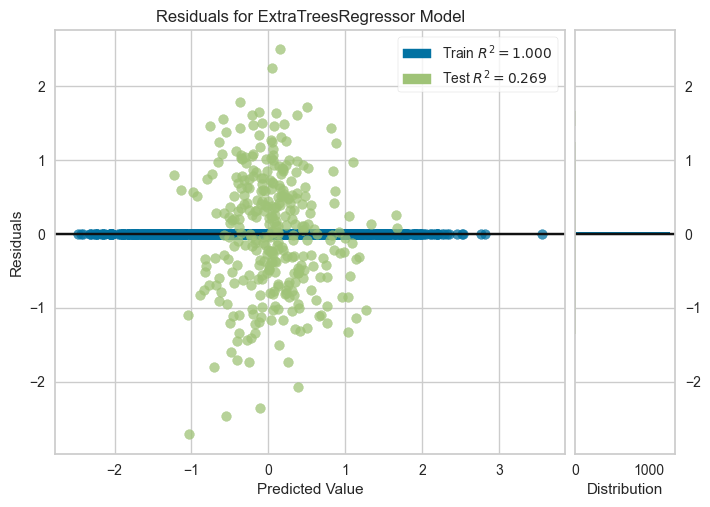

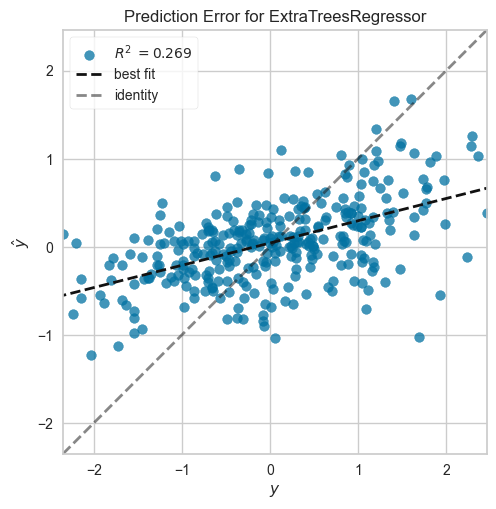

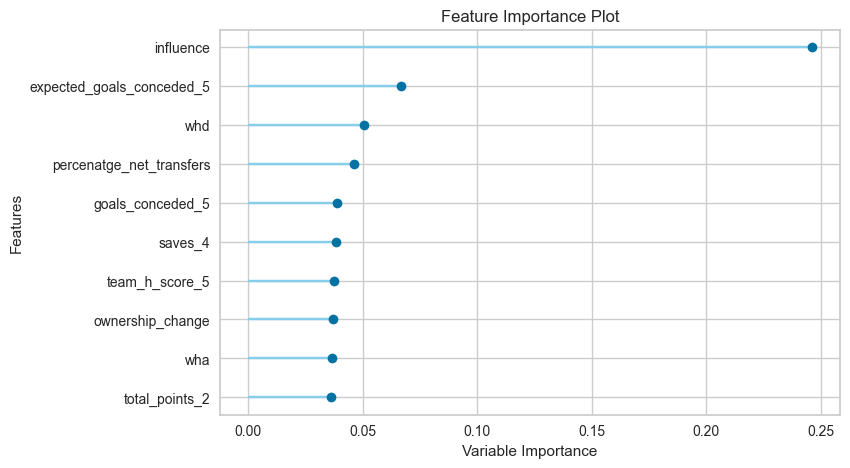

In [42]:
base_g_xgc_model = setup(g_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_xgc_best = base_g_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_g_xgc_best)

print('Évaluate the model...')
evaluate_model(base_g_xgc_best)

print('Plots...')
plot_model(base_g_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_xgc_best, plot='error')          # Prediction error plot
plot_model(base_g_xgc_best, plot='feature')        # Feature importance

### Blended Model


In [43]:
blend_g_xgc_model = setup(g_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

g_xgc_best = compare_models(n_select=3, sort='MAE')
print(g_xgc_best)

print('Blended model')
# Ensemble (blend or stack)
g_xgc_blended = blend_models(g_xgc_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000474 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3007
[LightGBM] [Info] Number of data points in the train set: 1289, number of used features: 67
[LightGBM] [Info] Start training from score 0.010260


,Description,Value
0,Session id,4462
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(1612, 108)"
4,Transformed data shape,"(1612, 22)"
5,Transformed train set shape,"(1289, 22)"
6,Transformed test set shape,"(323, 22)"
7,Numeric features,106
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.7066,0.7602,0.8706,0.2309,0.4106,2.0947,0.5720
rf,Random Forest Regressor,0.7079,0.7621,0.8716,0.2286,0.4150,2.0424,1.0610
ridge,Ridge Regression,0.7083,0.7565,0.8682,0.2349,0.4030,1.9584,0.2350
lr,Linear Regression,0.7085,0.7573,0.8686,0.2341,0.4028,1.9570,0.2510
br,Bayesian Ridge,0.7101,0.7571,0.8686,0.2345,0.4051,1.8722,0.2350
et,Extra Trees Regressor,0.7113,0.7671,0.8745,0.2221,0.4091,2.0422,0.7630
lar,Least Angle Regression,0.7182,0.7797,0.8803,0.2146,0.4015,2.2194,0.3270
ada,AdaBoost Regressor,0.7237,0.7820,0.8831,0.2100,0.4437,1.7141,0.3850
omp,Orthogonal Matching Pursuit,0.7263,0.7846,0.8843,0.2073,0.4181,1.9515,0.2490
en,Elastic Net,0.7263,0.7848,0.8845,0.2070,0.4250,1.8753,0.2860


[GradientBoostingRegressor(random_state=4462), RandomForestRegressor(n_jobs=-1, random_state=4462), Ridge(random_state=4462)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.7121,0.7498,0.8659,0.1295,0.3825,1.7579
1,0.7013,0.7584,0.8709,0.2455,0.4312,2.3005
2,0.7971,0.8645,0.9298,0.1543,0.4450,1.5686
3,0.7128,0.8127,0.9015,0.2445,0.4030,1.6256
4,0.7148,0.8069,0.8983,0.3174,0.4091,3.3978
5,0.7314,0.8172,0.9040,0.3271,0.4381,1.3820
6,0.6386,0.6152,0.7844,0.3378,0.3996,1.3873
7,0.6479,0.6319,0.7949,0.2169,0.3968,3.0096
8,0.6558,0.6703,0.8187,0.2413,0.3933,1.7834


### Save Model


In [44]:
g_xgc_final_model = finalize_model(g_xgc_blended)
save_model(g_xgc_final_model, './models/g_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                  TransformerWrapper(exclude=[],
                                     transformer=SelectFromModel(estimator=LGBMRegressor()

## Def


expected_goals_conceded
0.00    79
0.83    75
1.03    57
1.48    56
1.08    47
        ..
9.84     1
6.86     1
6.94     1
3.06     1
3.07     1
Name: count, Length: 386, dtype: int64


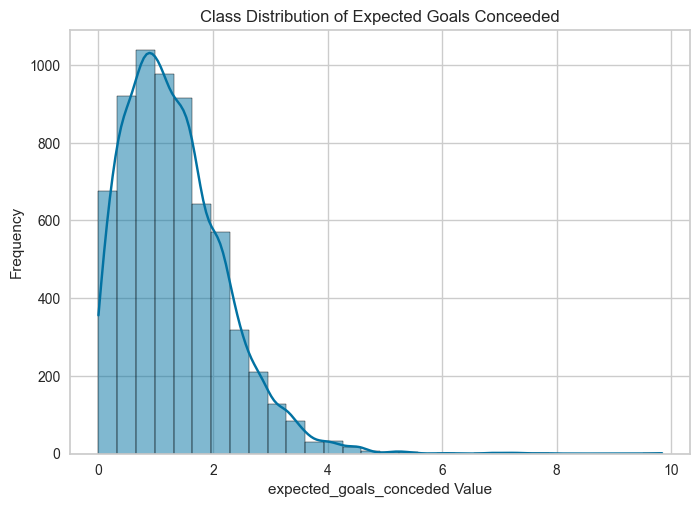

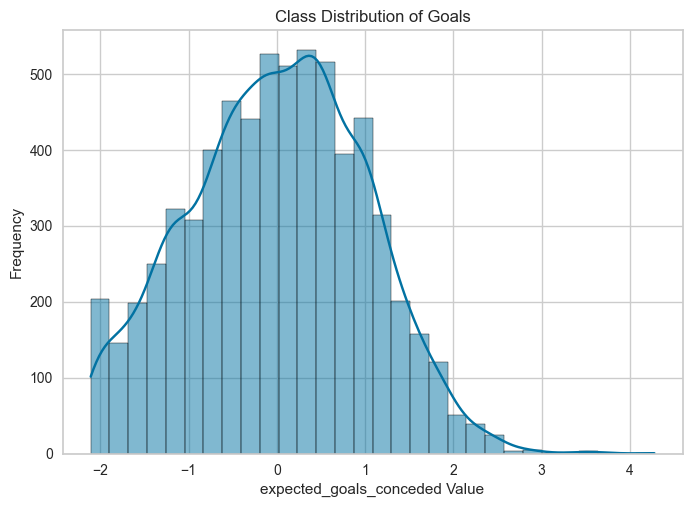

In [45]:
def_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xgc_data = def_xgc_data[xgc_features]
def_xgc_data_tar = def_xgc_data_tar[xgc_features]

def_xgc_data.reset_index(drop=True, inplace=True)
def_xgc_data.reset_index(drop=True, inplace=True)

def_xgc_data.drop(columns=['position'], inplace=True)
def_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(def_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xgc = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xgc.fit(def_xgc_data[['expected_goals_conceded']])
joblib.dump(pt_def_xgc, './models/pt_def_xgc.pkl')  # Save fitted transformer

def_xgc_data['expected_goals_conceded'] = pt_def_xgc.transform(def_xgc_data[['expected_goals_conceded']])


sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Goals')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004805 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6548
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 73
[LightGBM] [Info] Start training from score -0.003114


,Description,Value
0,Session id,7144
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(6573, 108)"
4,Transformed data shape,"(6573, 22)"
5,Transformed train set shape,"(5258, 22)"
6,Transformed test set shape,"(1315, 22)"
7,Numeric features,106
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.6259,0.6280,0.7909,0.3754,0.3778,1.8272,2.2380
lightgbm,Light Gradient Boosting Machine,0.6573,0.6808,0.8242,0.3229,0.3856,1.9969,0.8310
rf,Random Forest Regressor,0.6649,0.6937,0.8321,0.3101,0.4037,1.7049,4.4230
xgboost,Extreme Gradient Boosting,0.6652,0.7114,0.8429,0.2918,0.3749,2.2956,0.7140
gbr,Gradient Boosting Regressor,0.6859,0.7266,0.8517,0.2773,0.4140,1.8156,1.5370
ada,AdaBoost Regressor,0.7582,0.8604,0.9273,0.1435,0.4934,1.4311,0.9520
lr,Linear Regression,0.7654,0.8837,0.9398,0.1201,0.4543,1.7792,0.4910
ridge,Ridge Regression,0.7656,0.8837,0.9398,0.1202,0.4545,1.7794,0.6270
br,Bayesian Ridge,0.7671,0.8854,0.9407,0.1185,0.4578,1.7570,0.5040
en,Elastic Net,0.8013,0.9578,0.9784,0.0466,0.5298,1.3407,0.4530


ExtraTreesRegressor(n_jobs=-1, random_state=7144)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


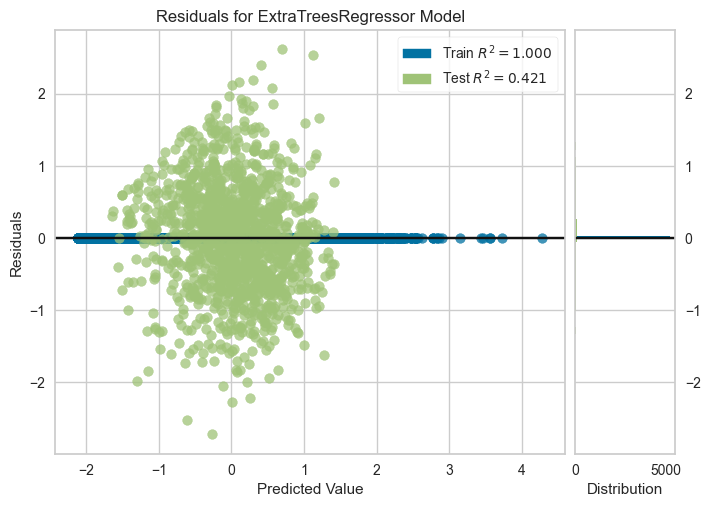

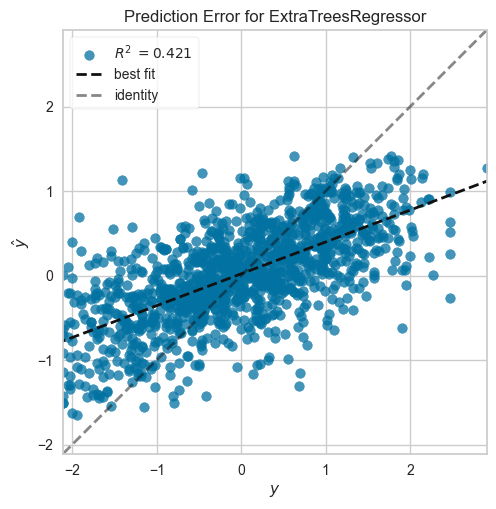

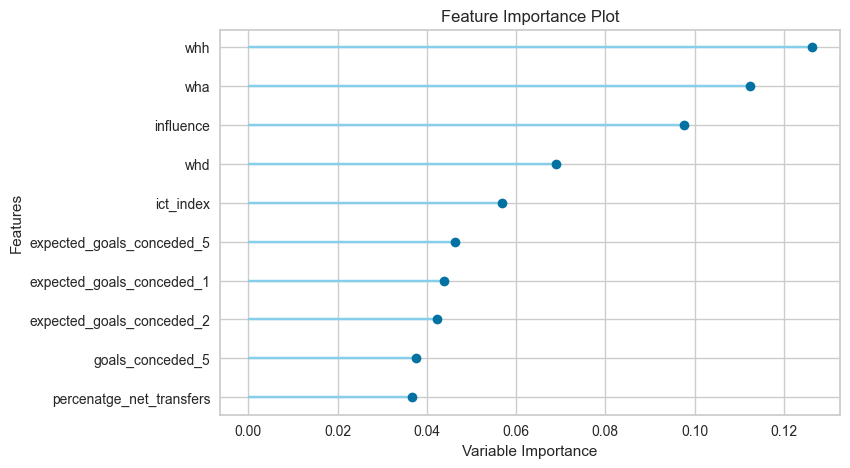

In [46]:
base_def_xgc_model = setup(def_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xgc_best = base_def_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_def_xgc_best)

print('Évaluate the model...')
evaluate_model(base_def_xgc_best)

print('Plots...')
plot_model(base_def_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xgc_best, plot='error')          # Prediction error plot
plot_model(base_def_xgc_best, plot='feature')        # Feature importance

### Blended Model


In [47]:
blend_def_xgc_model = setup(def_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

def_xgc_best = compare_models(n_select=3, sort='MAE')
print(def_xgc_best)

print('Blended model')
# Ensemble (blend or stack)
def_xgc_blended = blend_models(def_xgc_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004810 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6275
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 72
[LightGBM] [Info] Start training from score -0.002469


,Description,Value
0,Session id,1772
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(6573, 108)"
4,Transformed data shape,"(6573, 22)"
5,Transformed train set shape,"(5258, 22)"
6,Transformed test set shape,"(1315, 22)"
7,Numeric features,106
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.6711,0.6989,0.8337,0.3012,0.4094,1.8632,2.2410
lightgbm,Light Gradient Boosting Machine,0.6763,0.7123,0.8432,0.2876,0.4024,2.0022,0.6380
xgboost,Extreme Gradient Boosting,0.6815,0.7389,0.8583,0.2608,0.3823,2.2356,0.8490
rf,Random Forest Regressor,0.6945,0.7452,0.8626,0.2547,0.4226,1.7648,4.5260
gbr,Gradient Boosting Regressor,0.7091,0.7675,0.8755,0.2323,0.4302,1.8154,1.4630
lr,Linear Regression,0.7651,0.8804,0.9381,0.1192,0.4576,1.8082,0.5960
ridge,Ridge Regression,0.7652,0.8806,0.9382,0.1190,0.4577,1.8083,0.4540
br,Bayesian Ridge,0.7674,0.8828,0.9394,0.1168,0.4620,1.7897,0.5200
ada,AdaBoost Regressor,0.7682,0.8785,0.9371,0.1211,0.5029,1.4940,0.9210
en,Elastic Net,0.8006,0.9526,0.9759,0.0469,0.5319,1.3796,0.5770


[ExtraTreesRegressor(n_jobs=-1, random_state=1772), LGBMRegressor(n_jobs=-1, random_state=1772), XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cpu', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=-1,
             num_parallel_tree=None, random_state=1772, ...)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.6814,0.7230,0.8503,0.2662,0.4114,1.8839
1,0.5905,0.5616,0.7494,0.4319,0.3551,1.6576
2,0.6075,0.5659,0.7522,0.4263,0.3594,1.3296
3,0.6774,0.7032,0.8386,0.2758,0.4076,1.3990
4,0.6593,0.6927,0.8323,0.3016,0.4082,1.5056
5,0.6952,0.7456,0.8635,0.2850,0.4215,1.8906
6,0.6689,0.6781,0.8235,0.3195,0.4080,1.3731
7,0.6183,0.5922,0.7695,0.4070,0.3683,3.3195
8,0.6666,0.7132,0.8445,0.3053,0.3981,2.6136


In [48]:
tuned_blend = tune_model(def_xgc_blended, optimize='MAE', n_iter=10)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.6838,0.7335,0.8565,0.2555,0.4096,1.8166
1,0.5852,0.5524,0.7432,0.4412,0.3526,1.6566
2,0.6038,0.5609,0.7489,0.4313,0.3570,1.3202
3,0.6761,0.7026,0.8382,0.2763,0.4065,1.3987
4,0.6602,0.6948,0.8335,0.2995,0.4063,1.5101
5,0.6945,0.7468,0.8642,0.2838,0.4190,1.9739
6,0.6690,0.6788,0.8239,0.3188,0.4059,1.3735
7,0.6144,0.5884,0.7671,0.4108,0.3657,3.3075
8,0.6652,0.7080,0.8414,0.3104,0.3985,2.6295


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [49]:
def_xgc_final_model = finalize_model(tuned_blend)
save_model(def_xgc_final_model, './models/def_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                                                            interaction_constraints=None,
                                                 